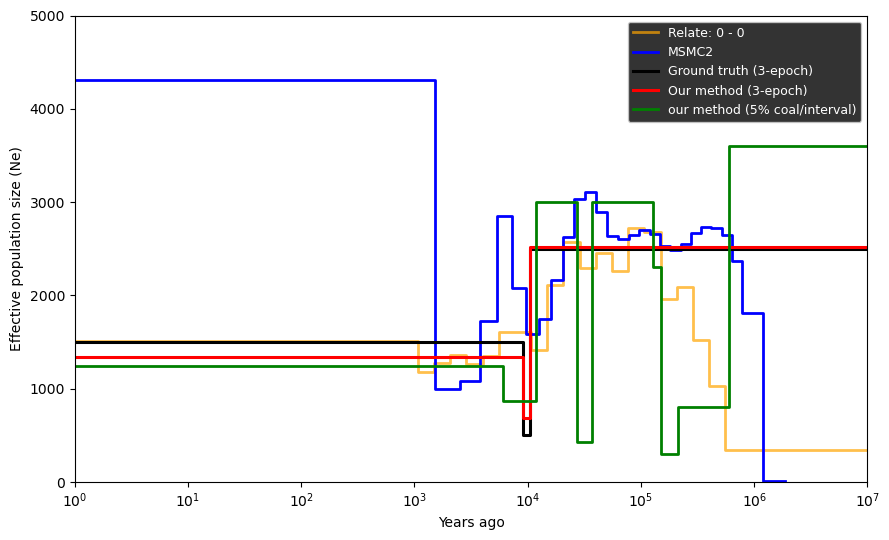

In [20]:
# plot_all_ne_with_polygon_legend.py
# Plot: Relate + MSMC2 + Ground truth (3-epoch) + Our method (3-epoch) + Polygon 5% coal/interval
# Clean white style, black axes/labels, no grid, legend labels forced.

import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= USER SETTINGS =========
MSMC_PATH  = "/space/s1/KaiyuanLi/Ne_estimate/three_intervals/msmc2/three_intervals.final.txt"
RELATE_ANC = "/space/s1/KaiyuanLi/Ne_estimate/three_intervals/relate_three_intervals_popsize.anc"

mu  = 1e-7     # per-site per-generation
gen = 30       # years per generation
T1_gen, T2_gen = 300, 350

TRUTH_NE = (1500.0, 500.0, 2500.0)
OURS_NE  = (1344.58, 692.38, 2522.14)

# Polygon 5% coal-per-interval (times in generations)
POLYGON_NE = np.array([
    1241.9, 864.68, 3000., 3000., 433.16, 3000., 3000., 3000., 3000.,
    3000., 3000., 2303.46, 300., 300., 805.92, 810.12, 807.11, 800.,
    800., 3607.
], dtype=float)
POLYGON_EDGES_GEN = np.array([
    0., 203.28664636, 396.75635352, 635.8426295, 917.22988843, 1235.31852792, 1593.03277959,
    1993.74188566, 2438.60614208, 2945.57167185, 3532.62012737, 4224.42830914, 5029.62089513,
    5977.51491856, 7091.40570674, 8442.37037801, 10119.98775789, 12296.64936225, 15294.64629212,
    19839.72323331, np.inf
], dtype=float)

USE_LOG_Y = False     # True => log y (like Relate R script); False => linear y (like MSMC2 tutorial)
YMAX      = 5000.0
RELATE_DIAGONAL_ONLY = False  # set True to only draw pop_i - pop_i lines from Relate
# =================================

def step_xy_from_intervals(left, right, value):
    x = np.ravel(np.column_stack([left, right]))
    y = np.ravel(np.column_stack([value, value]))
    return x, y

def step_xy_from_bins(edges, values):
    assert len(edges) == len(values) + 1, "edges must be one longer than values"
    left = edges[:-1]
    right = edges[1:]
    return step_xy_from_intervals(left, right, values)

def load_msmc2(path, mu, gen):
    df = pd.read_table(path, sep=r"\s+", header=0, engine="python")
    need = {"time_index", "left_time_boundary", "right_time_boundary", "lambda"}
    if not need.issubset(df.columns):
        raise ValueError(f"Unexpected MSMC2 columns: {df.columns.tolist()}")
    df = df[np.isfinite(df["lambda"]) & (df["lambda"] > 0)].copy()
    df["Years_left"]  = df["left_time_boundary"]  / mu * gen
    df["Years_right"] = df["right_time_boundary"] / mu * gen
    df["Ne"]          = 1.0 / (2.0 * mu * df["lambda"])
    # cap inf right boundary for plotting
    finite_right = df["Years_right"].replace([np.inf, -np.inf], np.nan).dropna()
    cap = (finite_right.quantile(0.999) * 1.05) if not finite_right.empty else df["Years_left"].max() * 1.2
    df.loc[~np.isfinite(df["Years_right"]), "Years_right"] = cap
    df.sort_values("Years_left", inplace=True)
    return df

def parse_coal_file(prefix_path: str):
    p = pathlib.Path(prefix_path)
    if p.suffix == ".anc":
        p = p.with_suffix(".coal")
    elif p.suffix != ".coal":
        p = p.with_suffix(".coal")
    with open(p, "r") as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    if len(lines) < 3:
        raise ValueError(f"Coal file too short: {p}")
    groups = lines[0].split()
    t_gen = np.array([float(x) for x in lines[1].split()], dtype=float)
    rows = []
    for ln in lines[2:]:
        toks = ln.split()
        if len(toks) < 3:
            continue
        try:
            arr = np.array([float(x) for x in toks], dtype=float)
        except ValueError:
            continue
        rows.append(arr)
    if not rows:
        raise ValueError(f"No usable pair rows in {p}")
    return groups, t_gen, rows, p

def infer_layout_and_num_pops(num_rows: int):
    P_sq = int(round(np.sqrt(num_rows)))
    if P_sq * P_sq == num_rows:
        return "square", P_sq
    disc = 1 + 8 * num_rows
    root = int(np.sqrt(disc))
    if root * root == disc:
        n = (-1 + root) // 2
        if n * (n + 1) // 2 == num_rows:
            return "triangular", int(n)
    raise ValueError(f"Cannot infer num_pops from rows={num_rows}")

def build_relate_popsize_df(groups, t_gen, rows, years_per_gen: float):
    layout, num_pops = infer_layout_and_num_pops(len(rows))
    if len(groups) < num_pops:
        groups = groups[:num_pops]
    t_years = years_per_gen * t_gen
    t_years = np.minimum(t_years, 1e7)
    frames = []
    if layout == "square":
        for p1 in range(1, num_pops + 1):
            for p2 in range(1, p1 + 1):
                idx = (p1 - 1) * num_pops + (p2 - 1)
                arr = rows[idx]
                if arr.size <= 2:
                    continue
                c = arr[2:]
                if c.size != t_years.size:
                    continue
                pop_size = 0.5 / c
                label = f"{groups[p1-1]} - {groups[p2-1]}"
                frames.append(pd.DataFrame({"time": t_years, "pop_size": pop_size, "groups": label}))
    else:
        k = 0
        for p1 in range(1, num_pops + 1):
            for p2 in range(1, p1 + 1):
                arr = rows[k]; k += 1
                if arr.size <= 2:
                    continue
                c = arr[2:]
                if c.size != t_years.size:
                    continue
                pop_size = 0.5 / c
                label = f"{groups[p1-1]} - {groups[p2-1]}"
                frames.append(pd.DataFrame({"time": t_years, "pop_size": pop_size, "groups": label}))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["time","pop_size","groups"])

def build_three_epoch_xy(T1_gen, T2_gen, Ne_tuple, gen, x_right_hint=None):
    Ne1, Ne2, Ne3 = Ne_tuple
    y = np.array([Ne1, Ne2, Ne3], dtype=float)
    years_T1 = T1_gen * gen
    years_T2 = T2_gen * gen
    right = years_T2 * 10.0
    if x_right_hint is not None:
        right = max(right, float(x_right_hint))
    left_arr  = np.array([0.0, years_T1, years_T2])
    right_arr = np.array([years_T1, years_T2, right])
    return step_xy_from_intervals(left_arr, right_arr, y)

def main():
    # MSMC2
    msmc = load_msmc2(MSMC_PATH, mu, gen)
    msmc_x, msmc_y = step_xy_from_intervals(msmc["Years_left"].values,
                                            msmc["Years_right"].values,
                                            msmc["Ne"].values)

    # Relate
    groups, t_gen_vec, rows, coal_path = parse_coal_file(RELATE_ANC)
    relate_long = build_relate_popsize_df(groups, t_gen_vec, rows, years_per_gen=gen)
    if RELATE_DIAGONAL_ONLY and not relate_long.empty:
        diag_labels = {f"{g} - {g}" for g in groups[:len(groups)]}
        relate_long = relate_long[relate_long["groups"].isin(diag_labels)].copy()

    # Determine right bound across datasets
    xmax_candidates = []
    if not relate_long.empty:
        xmax_candidates.append(relate_long["time"].max())
    if not msmc.empty:
        xmax_candidates.append(msmc["Years_right"].max())
    x_right_hint = max(xmax_candidates) if xmax_candidates else None

    # Truth & Ours
    truth_x, truth_y = build_three_epoch_xy(T1_gen, T2_gen, TRUTH_NE, gen, x_right_hint)
    ours_x,  ours_y  = build_three_epoch_xy(T1_gen, T2_gen, OURS_NE,  gen, x_right_hint)

    # Polygon (convert edges to years)
    poly_edges_years = POLYGON_EDGES_GEN * gen
    if np.isinf(poly_edges_years[-1]) and x_right_hint is not None:
        poly_edges_years[-1] = float(x_right_hint)
    poly_x, poly_y = step_xy_from_bins(poly_edges_years, POLYGON_NE)

    # Axis limits
    xmin = max(1.0, np.nanmin([
        relate_long["time"].min() if not relate_long.empty else np.inf,
        msmc["Years_left"].min() if not msmc.empty else np.inf,
        poly_edges_years[0] if len(poly_edges_years) else np.inf
    ]))
    xmax = max(
        truth_x.max(), ours_x.max(),
        msmc["Years_right"].max() if not msmc.empty else 1.0,
        relate_long["time"].max() if not relate_long.empty else 1.0,
        poly_edges_years[-1] if len(poly_edges_years) else 1.0
    )

    # === Plot ===
    plt.figure(figsize=(9, 5.5), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.tick_params(colors="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

    plt.xscale("log")
    if USE_LOG_Y:
        plt.yscale("log")

    handles, labels = [], []

    # Relate (potentially many lines)
    for grp, sub in relate_long.groupby("groups"):
        sub = sub.sort_values("time")
        h, = plt.step(sub["time"].values, sub["pop_size"].values, where="post",
                      linewidth=2.0, alpha=0.7, label=f"Relate: {grp}",color="orange")
        handles.append(h); labels.append(f"Relate: {grp}")

    # MSMC2
    h, = plt.plot(msmc_x, msmc_y, linewidth=2.0, color="blue", label="MSMC2")
    handles.append(h); labels.append("MSMC2")

    # Truth & Ours
    h, = plt.plot(truth_x, truth_y, linewidth=2.2, color="black", label="Ground truth (3-epoch)")
    handles.append(h); labels.append("Ground truth (3-epoch)")

    h, = plt.plot(ours_x, ours_y, linewidth=2.2, color="red", label="Our method (3-epoch)")
    handles.append(h); labels.append("Our method (3-epoch)")

    # Polygon
    h, = plt.plot(poly_x, poly_y, linewidth=2.0, color="green", label="Polygon (5% coal/interval)")
    handles.append(h); labels.append("our method (5% coal/interval)")

    plt.xlabel("Years ago", color="black")
    plt.ylabel("Effective population size (Ne)", color="black")
    plt.xlim(xmin, xmax)
    if not USE_LOG_Y:
        plt.ylim(0, YMAX)

    # Explicit legend with collected handles/labels (prevents auto-dedup hiding)
    plt.legend(handles, labels, loc="best", fontsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
